# Tanzania Food Demand System & Nutritional Adequacy Analysis
**Data:** Tanzania National Panel Survey (NPS/HBS) 2019–20  
**Recall period:** 7-day household food recall  
**Sample:** 1,110 households across Mainland Rural, Mainland Other Urban, Dar es Salaam, Zanzibar

---
### Outline
1. Setup & data loading  
2. Data cleaning and food group mapping  
3. Quantities, prices, and budget shares  
4. LA-AIDS demand system estimation  
5. Expenditure elasticities & Engel curves  
6. Nutrient intake computation (FCT mapping)  
7. Household RDA calculation  
8. Deficiency rates and adequacy ratios  
9. Regional and demographic heterogeneity  
10. Policy simulations  
11. Summary & policy recommendations


## 0. Setup

In [14]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ── Notebook display settings
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.3f}'.format)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'font.family': 'sans-serif',
})

# ── Path — adjust if your file is elsewhere 
DATA_PATH = 'Tanzania-Schultz.xlsx'
RECALL_DAYS = 7  # 7-day food recall period


## 1. Load Raw Data

In [15]:
xl = pd.ExcelFile(DATA_PATH)
print("Sheets available:", xl.sheet_names)

exp   = pd.read_excel(DATA_PATH, sheet_name='Food Expenditures (2019-20)')
prices_raw = pd.read_excel(DATA_PATH, sheet_name='Food Prices (2019-20)')
hh    = pd.read_excel(DATA_PATH, sheet_name='Household Characteristics')
fct   = pd.read_excel(DATA_PATH, sheet_name='FCT')
rda   = pd.read_excel(DATA_PATH, sheet_name='RDAs').rename(columns={'Unnamed: 0': 'nutrient'})
cats  = pd.read_excel(DATA_PATH, sheet_name='Catagories')

print(f"\nExpenditure rows : {len(exp):,}  |  Unique HHs: {exp['i'].nunique()}")
print(f"Price rows       : {len(prices_raw):,}  |  Unique foods: {prices_raw['j'].nunique()}")
print(f"HH characteristics: {len(hh):,}  |  Unique HHs: {hh['i'].nunique()}")
print(f"FCT foods        : {fct['j'].nunique()}")
print(f"Nutrients in FCT : {fct.columns[1:].tolist()}")


Sheets available: ['Food Expenditures (2019-20)', 'Food Prices (2019-20)', 'Household Characteristics', '2021 nutrients consumed by food', '2021 avg nutrients by household', 'Food Expenditures (2020-21)', 'Food Prices (2020-21)', 'FCT', 'Catagories', 'THM guidelines', 'Sub. Farming', 'ruralurban', 'RDAs', 'Region Features']

Expenditure rows : 15,581  |  Unique HHs: 1110
Price rows       : 223  |  Unique foods: 59
HH characteristics: 22,433  |  Unique HHs: 20576
FCT foods        : 67
Nutrients in FCT : ['Energy', 'Protein', 'Vitamin A', 'Vitamin D', 'Vitamin E', 'Vitamin C', 'Vitamin B-6', 'Vitamin B-12', 'Calcium', 'Magnesium', 'Iron', 'Zinc', 'Fiber']


In [16]:
# Quick look at each table
print("=== Food Expenditures ===")
display(exp.head(4))

print("\n=== Food Prices ===")
display(prices_raw.head(4))

print("\n=== Household Characteristics ===")
display(hh.head(3))

print("\n=== FCT (Food Composition Table) ===")
print("Note: FCT values are in nutrient units per KG of food")
display(fct.head(5))

print("\n=== RDAs (daily, per person by age-sex group) ===")
display(rda)


=== Food Expenditures ===


,i,t,m,j,Expenditure
0,0001-001-001,2019-20,Mainland Rural,Cassava Fresh,1500.000
1,0001-001-001,2019-20,Mainland Rural,Chicken,10400.000
2,0001-001-001,2019-20,Mainland Rural,Cooking Oil,875.000
3,0001-001-001,2019-20,Mainland Rural,Leafy Greens,1757.143



=== Food Prices ===


,t,m,j,u,Price
0,2019-20,Dar Es Salaam,Beef,kg,6532.212
1,2019-20,Dar Es Salaam,Bottled Beer,kg,4538.028
2,2019-20,Dar Es Salaam,Bread,kg,2422.511
3,2019-20,Dar Es Salaam,"Buns, Cakes And Biscuits",kg,2538.133



=== Household Characteristics ===


,i,t,m,Males 00-03,Females 00-03,Males 04-08,Females 04-08,Males 09-13,Females 09-13,Males 14-18,Females 14-18,Males 19-30,Females 19-30,Males 31-50,Females 31-50,Males 51-99,Females 51-99,hh size,log HSize
0,0001-001,2012-13,Mainland Rural,0,0,0,0,0,0,0,0,4,0,0,0,2,2,8,2.079
1,0001-001,2014-15,Mainland Rural,0,0,0,0,0,0,0,0,1,0,1,0,1,1,4,1.386
2,0001-004,2014-15,Mainland Rural,1,0,0,0,0,0,0,0,1,1,0,0,0,0,3,1.099



=== FCT (Food Composition Table) ===
Note: FCT values are in nutrient units per KG of food


,j,Energy,Protein,Vitamin A,Vitamin D,Vitamin E,Vitamin C,Vitamin B-6,Vitamin B-12,Calcium,Magnesium,Iron,Zinc,Fiber
0,Beef,3230,249.000,0.000,0,0,0,3.000,19.000,40.000,230,17.000,41.000,0
1,Bottled Beer,410,3.000,0.000,0,0,0,1.000,0.000,50.000,60,0.000,0.000,0
2,Bread,2740,80.000,0.000,0,0,0,0.000,0.000,100.000,270,5.000,9.000,28
3,"Butter, Etc.",8760,3.000,9250.000,20,30,0,0.000,0.000,80.000,10,1.000,0.000,0
4,Milk (dry or canned),4960,263.000,4070.000,0,10,70,4.000,30.000,8510.000,810,7.000,30.000,0



=== RDAs (daily, per person by age-sex group) ===


,nutrient,Males 00-03,Females 00-03,Males 04-08,Females 04-08,Males 09-13,Females 09-13,Males 14-18,Females 14-18,Males 19-30,Females 19-30,Males 31-50,Females 31-50,Males 51-99,Females 51-99
0,Energy,1000.000,1000.000,1400.000,1200.000,1800.000,1600.000,2200.000,1800.000,2400.000,2000.000,2200.000,1800.000,2000.000,1600.000
1,Protein,13.000,13.000,19.000,19.000,34.000,34.000,52.000,46.000,56.000,46.000,56.000,46.000,56.000,46.000
2,Vitamin A,300.000,300.000,400.000,400.000,600.000,600.000,900.000,700.000,900.000,700.000,900.000,700.000,900.000,700.000
3,Vitamin D,15.000,15.000,20.000,20.000,20.000,20.000,20.000,20.000,20.000,20.000,20.000,20.000,20.000,20.000
4,Vitamin E,6.000,6.000,7.000,7.000,11.000,11.000,15.000,15.000,15.000,15.000,15.000,15.000,15.000,15.000
5,Vitamin C,15.000,15.000,25.000,25.000,45.000,45.000,75.000,65.000,90.000,75.000,90.000,75.000,90.000,75.000
6,Vitamin B-6,0.500,0.500,0.600,0.600,1.000,1.000,1.300,1.200,1.300,1.300,1.300,1.300,1.700,1.500
7,Vitamin B-12,0.900,0.900,1.200,1.200,1.800,1.800,2.400,2.400,2.400,2.400,2.400,2.400,2.400,2.400
8,Calcium,700.000,700.000,1000.000,1000.000,1300.000,1300.000,1300.000,1300.000,1000.000,1000.000,1000.000,1000.000,1000.000,1200.000
9,Magnesium,80.000,80.000,130.000,130.000,240.000,240.000,410.000,360.000,400.000,310.000,420.000,320.000,420.000,320.000


## 2. Food Group Mapping

We aggregate the 56 food items into **8 groups** for demand system estimation.
The Categories sheet has slightly different food name spellings, so we use a manual mapping.


In [17]:
# Manual food-to-group mapping (aligns with the 56 foods in expenditure data)
FOOD_GROUP = {
    # Grains / Cereals / Starchy foods
    'Bread':                      'Grains',
    'Buns, Cakes And Biscuits':   'Grains',
    'Cassava Dry/Flour':          'Grains',
    'Cassava Fresh':              'Grains',
    'Irish Potatoes':             'Grains',
    'Macaroni, Spaghetti':        'Grains',
    'Maize (flour)':              'Grains',
    'Maize (grain)':              'Grains',
    'Maize (green, cob)':         'Grains',
    'Millet & Sorghum (flour)':   'Grains',
    'Other Cereal Products':      'Grains',
    'Other Cereals':              'Grains',
    'Other Starches':             'Grains',
    'Rice (husked)':              'Grains',
    'Rice (paddy)':               'Grains',
    'Sweet Potatoes':             'Grains',
    'Wheat Flour':                'Grains',
    'Yams/Cocoyams':              'Grains',
    # Meat / Fish / Eggs
    'Beef':                       'Meat',
    'Chicken':                    'Meat',
    'Eggs':                       'Meat',
    'Fish (dried)':               'Meat',
    'Fish (fresh)':               'Meat',
    'Goat Meat':                  'Meat',
    'Other Meat':                 'Meat',
    'Pork':                       'Meat',
    # Dairy
    'Butter, Etc.':               'Dairy',
    'Dairy Products':             'Dairy',
    'Milk (dry or canned)':       'Dairy',
    'Milk (fresh)':               'Dairy',
    # Vegetables
    'Leafy Greens':               'Vegetables',
    'Vegetables (fresh)':         'Vegetables',
    'Vegetables (preserved)':     'Vegetables',
    # Fruit
    'Citrus Fruits':              'Fruit',
    'Coconuts':                   'Fruit',
    'Honey, Syrups, etc.':        'Fruit',
    'Other Fruits':               'Fruit',
    'Plantains':                  'Fruit',
    'Ripe Bananas':               'Fruit',
    'Sugarcane':                  'Fruit',
    # Pulses / Nuts / Seeds
    'Groundnuts':                 'Pulses',
    'Nuts':                       'Pulses',
    'Pulses':                     'Pulses',
    'Seeds':                      'Pulses',
    # Cooking / Condiments
    'Cooking Oil':                'Cooking',
    'Materials For Drinks':       'Cooking',
    'Other Spices':               'Cooking',
    'Salt':                       'Cooking',
    'Sugar':                      'Cooking',
    # Luxury / Beverages
    'Bottled Beer':               'Luxury',
    'Coffee & Cocoa':             'Luxury',
    'Local Brews':                'Luxury',
    'Soft drinks':                'Luxury',
    'Sweets':                     'Luxury',
    'Tea (dry)':                  'Luxury',
    'Wine & Spirits':             'Luxury',
}

exp['group'] = exp['j'].map(FOOD_GROUP).fillna('Grains')

# Verify all 56 foods are mapped
unmapped = set(exp['j'].unique()) - set(FOOD_GROUP.keys())
print(f"Unmapped foods: {unmapped if unmapped else 'None — all foods mapped!'}")
print("\nFoods per group:")
print(exp.groupby('group')['j'].nunique().sort_values(ascending=False))


Unmapped foods: None — all foods mapped!

Foods per group:
group
Grains        18
Meat           8
Luxury         7
Fruit          7
Cooking        5
Dairy          4
Pulses         4
Vegetables     3
Name: j, dtype: int64


## 3. Prices, Quantities, and Budget Shares

**Price:** median regional unit value (TZS/kg). Fall back to national median when region has no price.  
**Quantity:** `qty_kg = expenditure (TZS) / price (TZS/kg)` → kilograms consumed over the 7-day recall.


In [18]:
# Build regional and national median prices
prices_raw = prices_raw.dropna(subset=['Price'])
nat_price = prices_raw.groupby('j')['Price'].median().rename('nat_price')
reg_price = (prices_raw.groupby(['m','j'])['Price']
             .median().reset_index().rename(columns={'Price': 'price'}))

# Merge onto expenditure
exp = (exp.merge(reg_price, on=['m','j'], how='left')
          .merge(nat_price,  on='j',      how='left'))
exp['price'] = exp['price'].fillna(exp['nat_price'])
exp = exp.dropna(subset=['price'])

# Quantities (kg)
exp['qty_kg'] = exp['Expenditure'] / exp['price']

print(f"Rows after price merge: {len(exp):,}")
print("\nSample rows:")
display(exp[['i','m','j','group','Expenditure','price','qty_kg']].head(6))


Rows after price merge: 15,581

Sample rows:


,i,m,j,group,Expenditure,price,qty_kg
0,0001-001-001,Mainland Rural,Cassava Fresh,Grains,1500.000,702.740,2.135
1,0001-001-001,Mainland Rural,Chicken,Meat,10400.000,7308.232,1.423
2,0001-001-001,Mainland Rural,Cooking Oil,Cooking,875.000,3596.039,0.243
3,0001-001-001,Mainland Rural,Leafy Greens,Vegetables,1757.143,1231.114,1.427
4,0001-001-001,Mainland Rural,Millet & Sorghum (flour),Grains,10500.000,1587.229,6.615
5,0001-001-001,Mainland Rural,Salt,Cooking,200.000,1078.901,0.185


In [19]:
# Household-level total food expenditure
hh_tot = exp.groupby('i')['Expenditure'].sum().rename('x_food')

# Group expenditure and budget shares
grp_exp = (exp.groupby(['i','group'])['Expenditure']
              .sum().reset_index().rename(columns={'Expenditure':'grp_exp'}))
grp_exp = grp_exp.merge(hh_tot, on='i')
grp_exp['w'] = grp_exp['grp_exp'] / grp_exp['x_food']

print("Distribution of total food expenditure per household (TZS, 7-day recall):")
print(hh_tot.describe().round(0))


Distribution of total food expenditure per household (TZS, 7-day recall):
count       1110.000
mean       88211.000
std       650684.000
min          865.000
25%        26358.000
50%        39688.000
75%        59482.000
max     18030767.000
Name: x_food, dtype: float64


Mean budget shares by food group:
group
Grains       42.400
Meat         18.900
Fruit        10.000
Vegetables    9.500
Cooking       8.200
Pulses        6.200
Dairy         2.500
Luxury        2.400


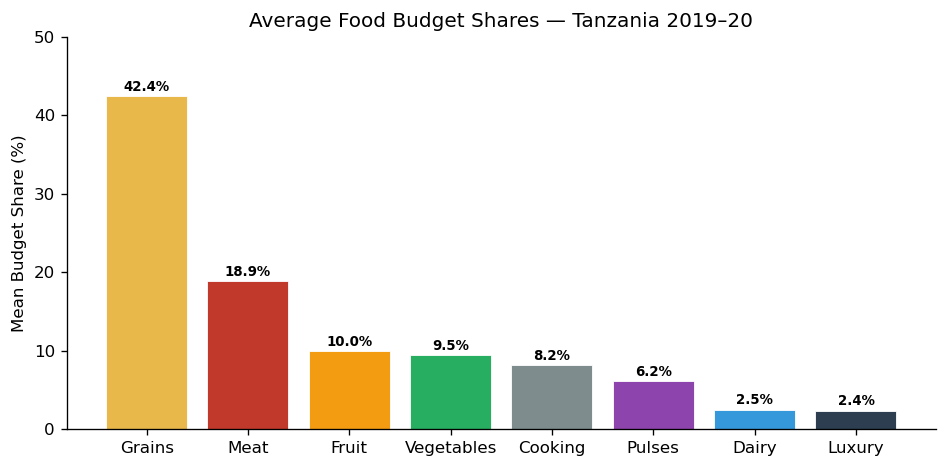

In [20]:
# Wide format: one row per HH, one column per group
w_wide = grp_exp.pivot(index='i', columns='group', values='w').fillna(0)

print("Mean budget shares by food group:")
mean_shares = w_wide.mean().sort_values(ascending=False)
print((mean_shares * 100).round(1).to_string())

# ── Bar chart of mean budget shares ──────────────────────────────────
GROUP_COLORS = {
    'Grains':'#E8B84B', 'Meat':'#C0392B', 'Fruit':'#F39C12',
    'Vegetables':'#27AE60', 'Cooking':'#7F8C8D', 'Pulses':'#8E44AD',
    'Dairy':'#3498DB', 'Luxury':'#2C3E50',
}
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(mean_shares.index, mean_shares.values * 100,
              color=[GROUP_COLORS.get(g,'grey') for g in mean_shares.index],
              edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, mean_shares.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val*100:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.set_ylabel('Mean Budget Share (%)')
ax.set_title('Average Food Budget Shares — Tanzania 2019–20')
ax.set_ylim(0, 50)
plt.tight_layout()
plt.show()


## 4. LA-AIDS Demand System Estimation

The **Linear Approximation Almost Ideal Demand System (LA-AIDS)** (Deaton & Muellbauer, 1980) models
budget shares as:

$$w_{ig} = \alpha_g + \sum_k \gamma_{gk} \ln(p_{ik}) + \beta_g \left[\ln(x_i) - \ln P^*_i\right] + \delta_g Z_i + \varepsilon_{ig}$$

where:
- $w_{ig}$ = budget share of group $g$ for household $i$  
- $p_{ik}$ = log unit value (price proxy) for group $k$  
- $x_i$ = total food expenditure  
- $\ln P^*_i = \sum_g w_{ig} \ln p_{ig}$ = Stone price index  
- $Z_i$ = household controls: log size, child share, region dummies  

Each equation is estimated by **OLS with HC3 robust standard errors**.


In [21]:
# ── Household characteristics (2019-20 only) ────────────────────────
demo_cols = [c for c in hh.columns if 'Males' in c or 'Females' in c]
hh19 = hh[hh['t'] == '2019-20'].copy().set_index('i')

hh19['adults']   = hh19[[c for c in demo_cols if any(a in c for a in ['19-30','31-50','51-99'])]].sum(axis=1)
hh19['children'] = hh19[[c for c in demo_cols if any(a in c for a in ['00-03','04-08','09-13'])]].sum(axis=1)
hh19['share_child']  = hh19['children'] / hh19['hh size'].clip(lower=1)
hh19['rural']        = (hh19['m'] == 'Mainland Rural').astype(int)
hh19['urban_main']   = (hh19['m'] == 'Mainland Other Urban').astype(int)
hh19['dares']        = (hh19['m'] == 'Dar Es Salaam').astype(int)

print(f"HHs in 2019-20: {len(hh19)}")
print("\nHousehold size distribution:")
print(hh19['hh size'].describe().round(1))
print("\nSample by region:")
print(hh19['m'].value_counts())


HHs in 2019-20: 1184

Household size distribution:
count   1184.000
mean       4.700
std        3.300
min        1.000
25%        3.000
50%        4.000
75%        6.000
max       35.000
Name: hh size, dtype: float64

Sample by region:
m
Mainland Rural          581
Mainland Other Urban    303
Dar Es Salaam           178
Zanzibar                122
Name: count, dtype: int64


In [22]:
# ── Group-level unit values (expenditure / qty) ──────────────────────
grp_qty = exp.groupby(['i','group'])['qty_kg'].sum().reset_index()
grp_e   = exp.groupby(['i','group'])['Expenditure'].sum().reset_index()
uv_df   = grp_e.merge(grp_qty, on=['i','group'])
uv_df['uv']    = uv_df['Expenditure'] / uv_df['qty_kg'].clip(lower=1e-6)
uv_df['ln_uv'] = np.log(uv_df['uv'].clip(lower=1))

lnp_wide = uv_df.pivot(index='i', columns='group', values='ln_uv')
# Fill missing with national median unit value
nat_lnuv = lnp_wide.median()
for c in lnp_wide.columns:
    lnp_wide[c] = lnp_wide[c].fillna(nat_lnuv[c])

# ── Stone price index: ln P* = Σ w_g * ln(p_g) ──────────────────────
stone = (w_wide * lnp_wide).sum(axis=1).rename('ln_stone')
ln_x  = np.log(hh_tot.clip(lower=1)).rename('ln_x')

# ── Assemble AIDS dataset ────────────────────────────────────────────
aids = (w_wide
        .join(lnp_wide, rsuffix='_lnp')
        .join(stone)
        .join(ln_x)
        .join(hh19[['hh size','log HSize','share_child','rural','urban_main','dares']]))
aids['ln_xP'] = aids['ln_x'] - aids['ln_stone']   # log real expenditure
aids = aids.dropna(subset=['ln_x','ln_stone','hh size'])

GROUPS   = sorted(set(exp['group'].unique()))
lnp_cols = [g + '_lnp' for g in GROUPS]

print(f"AIDS estimation dataset: {len(aids)} households × {len(GROUPS)} groups")
print(f"Groups: {GROUPS}")


AIDS estimation dataset: 1110 households × 8 groups
Groups: ['Cooking', 'Dairy', 'Fruit', 'Grains', 'Luxury', 'Meat', 'Pulses', 'Vegetables']


In [23]:
# ── Estimate one OLS equation per group ─────────────────────────────
demand_res = {}
coefs      = {}

for g in GROUPS:
    if g not in aids.columns:
        continue
    y    = aids[g]
    Xcols = [c for c in lnp_cols if c in aids.columns] +             ['ln_xP', 'log HSize', 'share_child', 'rural', 'urban_main', 'dares']
    X    = sm.add_constant(aids[Xcols])
    mask = y.notna() & X.notna().all(axis=1)
    res  = OLS(y[mask], X[mask]).fit(cov_type='HC3')
    demand_res[g] = res
    coefs[g] = {
        'alpha': res.params.get('const', 0),
        'beta':  res.params.get('ln_xP', 0),
        'gamma': {c.replace('_lnp',''): res.params.get(c, 0) for c in lnp_cols if c in res.params},
    }

# ── Summary table ───────────────────────────────────────────────────
summary = pd.DataFrame({
    'Mean Share (%)': (w_wide.mean()*100).round(1),
    'R²': {g: round(demand_res[g].rsquared, 3) for g in demand_res},
    'β (Real Exp.)': {g: round(coefs[g]['beta'], 4) for g in coefs},
    'N': {g: int(demand_res[g].nobs) for g in demand_res},
}).loc[GROUPS]

print("LA-AIDS Estimation Summary:")
display(summary)


LA-AIDS Estimation Summary:


,Mean Share (%),R²,β (Real Exp.),N
Cooking,8.200,0.167,-0.010,1110
Dairy,2.500,0.072,0.008,1110
Fruit,10.000,0.143,0.037,1110
Grains,42.400,0.230,0.014,1110
Luxury,2.400,0.209,-0.021,1110
Meat,18.900,0.108,-0.007,1110
Pulses,6.200,0.133,-0.008,1110
Vegetables,9.500,0.215,-0.012,1110


## Unit Test

In [24]:

# Check that the Stone price index was created
assert 'ln_stone' in aids.columns, "Stone price index column is missing"

# Check that the Stone price index has no missing values
assert aids['ln_stone'].notna().all(), "Stone price index contains missing values"

# Check that the real expenditure variable was created
assert 'ln_xP' in aids.columns, "Real expenditure variable ln_xP is missing"

# Check that real expenditure is correctly calculated as log expenditure minus Stone price index
assert np.allclose(
    aids['ln_xP'],
    aids['ln_x'] - aids['ln_stone']
), "ln_xP calculation is incorrect"

# Check that at least one demand equation was estimated
assert len(demand_res) > 0, "No demand equations were estimated"

# Check that each regression result is statistically valid
for g, res in demand_res.items():
    assert res.nobs > 0, f"No observations were used in the regression for {g}"
    assert 0 <= res.rsquared <= 1, f"Invalid R-squared value for {g}"
    assert np.isfinite(res.params).all(), f"Non-finite coefficient estimates found for {g}"

# Check that coefficient outputs are complete for each food group
for g in demand_res:
    assert g in coefs, f"Missing coefficient results for {g}"
    assert 'alpha' in coefs[g], f"Missing alpha coefficient for {g}"
    assert 'beta' in coefs[g], f"Missing beta coefficient for {g}"
    assert 'gamma' in coefs[g], f"Missing gamma coefficients for {g}"

## 5. Expenditure Elasticities and Engel Curves

Expenditure elasticities (ε > 1 = luxury, ε < 1 = necessity):
Fruit        1.371
Dairy        1.315
Grains       1.032
Meat         0.961
Cooking      0.882
Vegetables   0.875
Pulses       0.868
Luxury       0.090


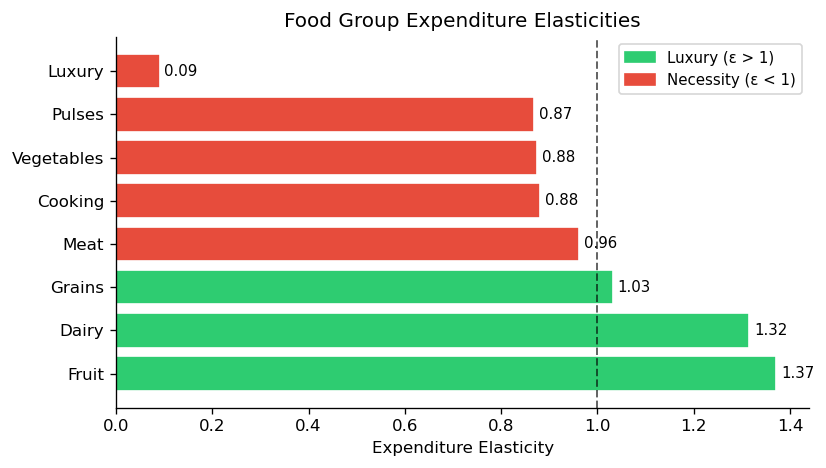

In [25]:
# Expenditure elasticity at sample mean: ε_g = 1 + β_g / w̄_g
w_mean = w_wide.mean()
exp_elast = pd.Series({
    g: 1 + coefs[g]['beta'] / max(w_mean.get(g, 0.001), 0.001)
    for g in coefs
}).sort_values(ascending=False)

print("Expenditure elasticities (ε > 1 = luxury, ε < 1 = necessity):")
print(exp_elast.round(3).to_string())

# ── Elasticity bar chart ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#2ECC71' if e > 1 else '#E74C3C' for e in exp_elast.values]
bars = ax.barh(exp_elast.index, exp_elast.values, color=colors, edgecolor='white')
ax.axvline(1, color='black', linestyle='--', linewidth=1.2, alpha=0.6, label='Unit elasticity')
for bar, val in zip(bars, exp_elast.values):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9)
ax.set_xlabel('Expenditure Elasticity')
ax.set_title('Food Group Expenditure Elasticities')
ax.legend(fontsize=9)
lux_p = mpatches.Patch(color='#2ECC71', label='Luxury (ε > 1)')
nec_p = mpatches.Patch(color='#E74C3C', label='Necessity (ε < 1)')
ax.legend(handles=[lux_p, nec_p], fontsize=9)
plt.tight_layout()
plt.show()


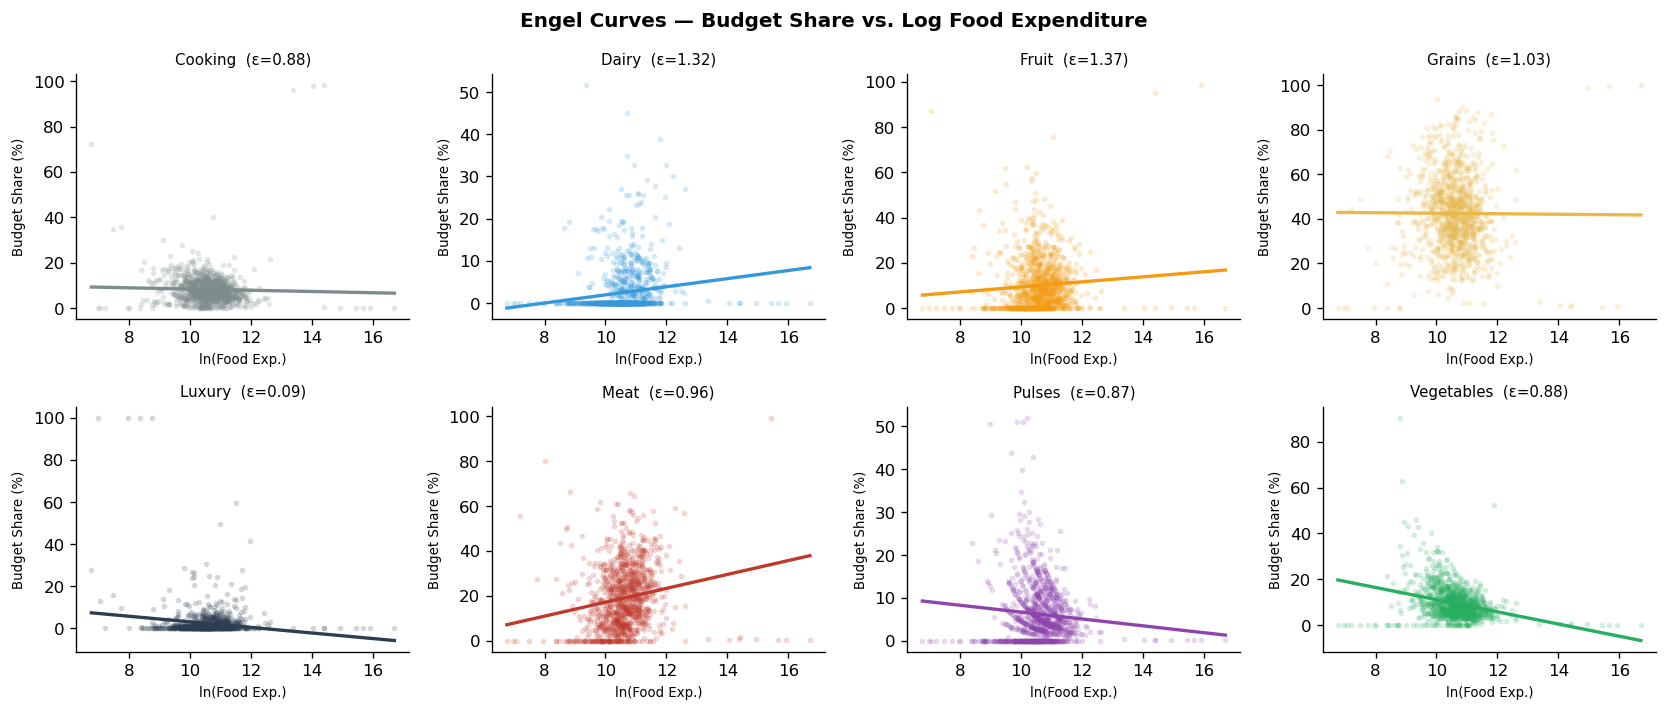

Positive slope = luxury; negative slope = necessity


In [26]:
# ── Engel Curves (budget share vs log total expenditure) ────────────
lnx_vals = aids['ln_x']
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
axes = axes.flatten()

for ax, g in zip(axes, GROUPS):
    if g not in aids.columns: continue
    y = aids[g] * 100
    ax.scatter(lnx_vals, y, alpha=0.15, s=6, color=GROUP_COLORS.get(g, 'grey'))
    mask = y.notna() & lnx_vals.notna()
    m, b = np.polyfit(lnx_vals[mask], y[mask], 1)
    xs = np.linspace(lnx_vals.min(), lnx_vals.max(), 100)
    ax.plot(xs, m*xs + b, color=GROUP_COLORS.get(g,'grey'), linewidth=2)
    ax.set_title(f'{g}  (ε={exp_elast.get(g,0):.2f})', fontsize=9)
    ax.set_xlabel('ln(Food Exp.)', fontsize=8)
    ax.set_ylabel('Budget Share (%)', fontsize=8)

plt.suptitle('Engel Curves — Budget Share vs. Log Food Expenditure', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print("Positive slope = luxury; negative slope = necessity")


## 6. Nutrient Intake Computation

The **FCT values are expressed per kilogram of food** (e.g., kcal/kg, g protein/kg, mg iron/kg).  
We multiply each food's quantity (kg) by its FCT row to get household-level nutrient totals.  
We then divide by `household size × RECALL_DAYS` to get per-capita daily intakes.


In [27]:
NUTRIENTS = ['Energy','Protein','Vitamin A','Vitamin D','Vitamin E','Vitamin C',
             'Vitamin B-6','Vitamin B-12','Calcium','Magnesium','Iron','Zinc','Fiber']

# Join FCT onto observed food quantities
obs = exp[['i','j','group','qty_kg']].merge(fct[['j'] + NUTRIENTS], on='j', how='left')

# Multiply quantity × FCT value (per kg)
for nut in NUTRIENTS:
    obs[nut] = obs[nut] * obs['qty_kg']

# Sum to household level (7-day total)
hh_nut = obs.groupby('i')[NUTRIENTS].sum()
hh_nut = hh_nut.join(hh19['hh size'])

# Convert to per-capita daily
hh_nut_daily = hh_nut[NUTRIENTS].div(hh_nut['hh size'] * RECALL_DAYS, axis=0)

print(f"Nutrient data for {len(hh_nut_daily)} households")
print("\nMean per-capita DAILY intake (should look physiologically plausible):")
display(hh_nut_daily.mean().round(2).rename('Mean Daily Intake').to_frame())


Nutrient data for 1110 households

Mean per-capita DAILY intake (should look physiologically plausible):


,Mean Daily Intake
Energy,4017.360
Protein,84.670
Vitamin A,1284.360
Vitamin D,6.850
Vitamin E,7.990
Vitamin C,70.130
Vitamin B-6,2.360
Vitamin B-12,1.310
Calcium,371.900
Magnesium,646.750


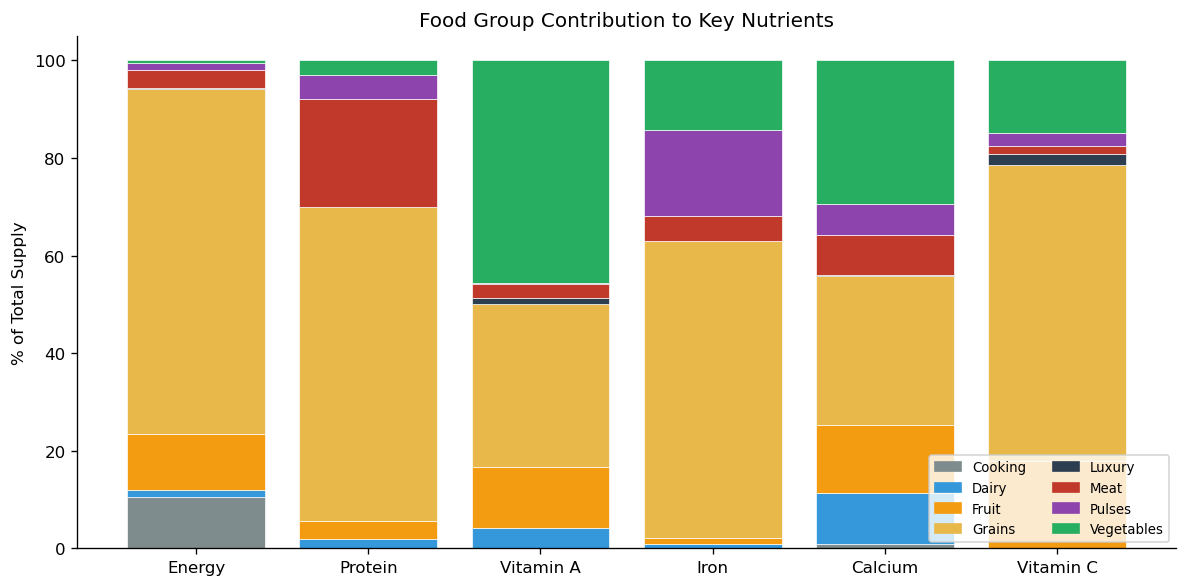

In [28]:
# ── Food group contribution to key nutrients ─────────────────────────
nut_by_group = obs.groupby('group')[NUTRIENTS].sum()
nut_pct = nut_by_group.div(nut_by_group.sum(axis=0), axis=1) * 100

focus = ['Energy','Protein','Vitamin A','Iron','Calcium','Vitamin C']
nut_pct_t = nut_pct[focus].T

fig, ax = plt.subplots(figsize=(10, 5))
bottom = np.zeros(len(focus))
for grp in nut_pct_t.columns:
    ax.bar(focus, nut_pct_t[grp], bottom=bottom,
           label=grp, color=GROUP_COLORS.get(grp,'grey'), edgecolor='white', linewidth=0.4)
    bottom += nut_pct_t[grp].values

ax.set_ylabel('% of Total Supply')
ax.set_title('Food Group Contribution to Key Nutrients')
handles = [mpatches.Patch(color=GROUP_COLORS.get(g,'grey'), label=g) for g in nut_pct_t.columns]
ax.legend(handles=handles, fontsize=8, ncol=2, loc='lower right')
plt.tight_layout()
plt.show()


## Unit Test

In [32]:
# Check that household-level dataset is not empty
assert len(hh_nut) > 0, "Household nutrient dataset is empty"

# Check that household size exists and is valid
assert 'hh size' in hh_nut.columns, "Household size missing in hh_nut"
assert (hh_nut['hh size'] > 0).all(), "Household size must be positive"

# Check that daily nutrient intake dataset exists
assert len(hh_nut_daily) > 0, "Daily nutrient dataset is empty"

# Check that no NaN values exist in final nutrient intake
assert hh_nut_daily.isnull().sum().sum() == 0, "NaN values found in daily nutrient intake"

# Check that nutrient intake values are finite
assert np.isfinite(hh_nut_daily.values).all(), "Non-finite values found in nutrient intake"

# Energy intake should be positive and within a reasonable range
assert (hh_nut_daily['Energy'] > 0).all(), "Energy intake must be positive"
assert hh_nut_daily['Energy'].mean() < 10000, "Energy intake seems unrealistically high"

# Protein intake should be positive
assert (hh_nut_daily['Protein'] >= 0).all(), "Protein intake must be positive"

## 7. Household-Specific RDA Calculation

For each household we compute a **per-capita daily RDA** by:
1. Summing each member's individual RDA (based on their age-sex group)  
2. Dividing by household size

This gives a household-specific benchmark that accounts for the age/sex composition of the household.


In [33]:
rda_idx = rda.set_index('nutrient')
demo_cols = [c for c in hh.columns if 'Males' in c or 'Females' in c]

hh_rda_pc = {}
for i, row in hh19[demo_cols].iterrows():
    n_members = max(hh19.loc[i, 'hh size'], 1)
    hh_rda_pc[i] = {}
    for nut in NUTRIENTS:
        total = 0.0
        for dc in demo_cols:
            if dc in rda_idx.columns and nut in rda_idx.index:
                total += row[dc] * rda_idx.loc[nut, dc]
        hh_rda_pc[i][nut] = total / n_members   # per-capita daily

rda_pc_df = pd.DataFrame(hh_rda_pc).T
rda_pc_df.index.name = 'i'

print("Mean per-capita daily RDA across sample households:")
display(rda_pc_df.mean().round(2).rename('Mean Daily RDA').to_frame())


Mean per-capita daily RDA across sample households:


,Mean Daily RDA
Energy,1794.030
Protein,41.050
Vitamin A,673.980
Vitamin D,19.400
Vitamin E,12.670
Vitamin C,63.540
Vitamin B-6,1.130
Vitamin B-12,2.030
Calcium,1027.220
Magnesium,292.290


## Unit Test

In [41]:
# Check that RDA table is not empty
assert len(rda_pc_df) > 0, "Household RDA dataset is empty"

# Check that all nutrients are included in the RDA dataset
for nut in NUTRIENTS:
    assert nut in rda_pc_df.columns, f"{nut} missing from RDA calculation"

# Check that household-level RDA values are non-negative
assert (rda_pc_df[NUTRIENTS] >= 0).all().all(), "Negative RDA values found"

# Check that RDA values are finite
assert np.isfinite(rda_pc_df[NUTRIENTS].values).all(), "Non-finite RDA values found"

# Check that household IDs are unique
assert rda_pc_df.index.is_unique, "Household IDs are not unique in RDA dataset"

# Check that each household has at least one positive RDA value
assert (rda_pc_df[NUTRIENTS].sum(axis=1) > 0).all(), "Some households have zero total RDA"

## 8. Deficiency Rates and Adequacy Ratios

**Adequacy ratio** = per-capita daily intake / per-capita daily RDA  
- Ratio ≥ 1.0 → household meets the RDA  
- Ratio < 1.0 → household is **deficient** in that nutrient

We report **two metrics**:
- **Deficiency rate**: % of households with adequacy ratio < 1.0  
- **Mean adequacy ratio**: average intake / RDA (a ratio < 1.0 means even the average HH is deficient)


In [34]:
# Align households present in both datasets
common_hh = hh_nut_daily.index.intersection(rda_pc_df.index)
intake     = hh_nut_daily.loc[common_hh]
rda_c      = rda_pc_df.loc[common_hh].clip(lower=0.01)

adequacy = intake / rda_c        # adequacy ratio
deficient = (adequacy < 1.0)     # boolean flag

def_rate   = deficient.mean().sort_values(ascending=False)
mean_adeq  = adequacy.mean().sort_values()

results_df = pd.DataFrame({
    'Deficiency Rate (%)': (def_rate * 100).round(1),
    'Mean Adequacy Ratio': mean_adeq.round(2),
    'Severity': pd.cut(def_rate, bins=[-1, 0.25, 0.50, 0.80, 1.0],
                       labels=['Low','Moderate','Severe','Critical'])
})

print("Nutritional Adequacy Summary:")
display(results_df.sort_values('Deficiency Rate (%)', ascending=False))


Nutritional Adequacy Summary:


,Deficiency Rate (%),Mean Adequacy Ratio,Severity
Vitamin D,97.900,0.350,Critical
Calcium,97.400,0.360,Critical
Vitamin E,86.400,0.630,Critical
Vitamin B-12,86.000,0.630,Critical
Vitamin C,65.900,1.140,Severe
Energy,47.500,2.330,Moderate
Zinc,46.500,1.790,Moderate
Fiber,40.000,1.620,Moderate
Vitamin A,40.000,1.920,Moderate
Protein,37.800,2.210,Moderate


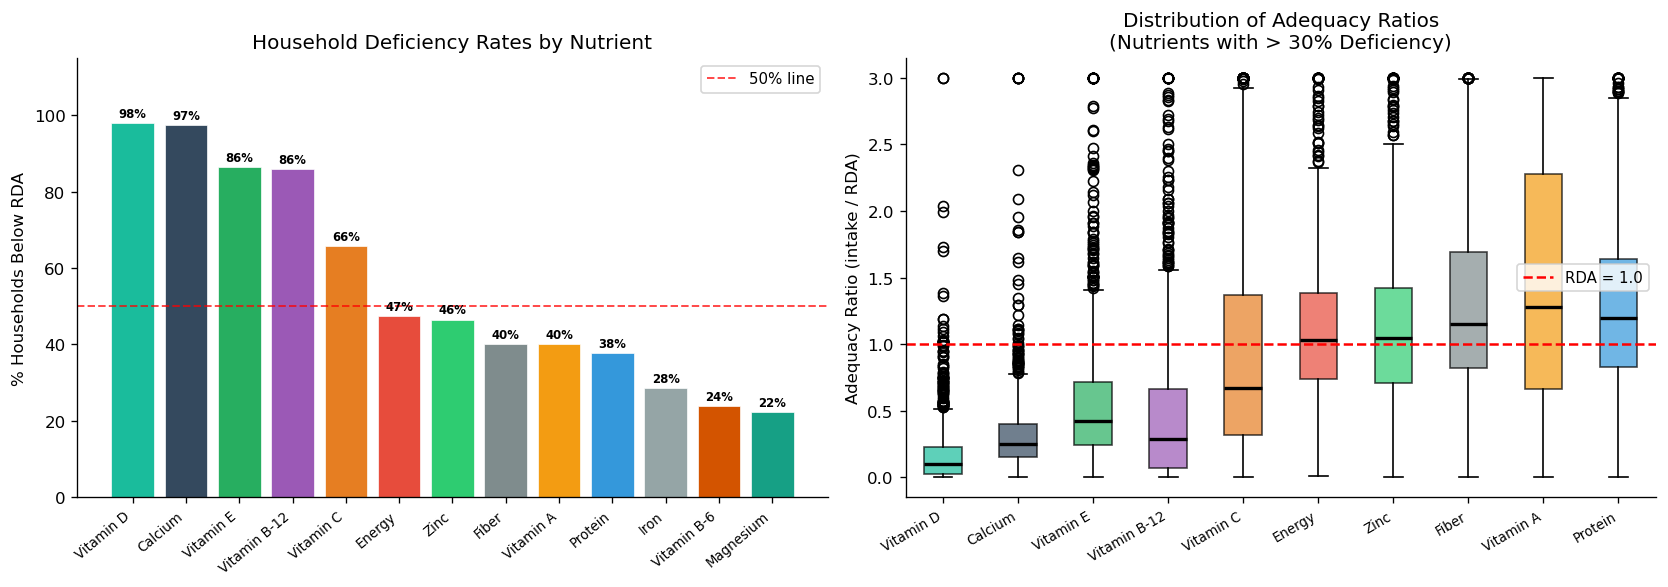

In [35]:
# ── Deficiency rate bar chart ─────────────────────────────────────────
NUT_COLORS = {
    'Energy':'#E74C3C', 'Protein':'#3498DB', 'Vitamin A':'#F39C12',
    'Vitamin D':'#1ABC9C', 'Vitamin E':'#27AE60', 'Vitamin C':'#E67E22',
    'Vitamin B-6':'#D35400', 'Vitamin B-12':'#9B59B6',
    'Calcium':'#34495E', 'Magnesium':'#16A085',
    'Iron':'#95A5A6', 'Zinc':'#2ECC71', 'Fiber':'#7F8C8D',
}

dr_sorted = def_rate.sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Deficiency rates
ax = axes[0]
bars = ax.bar(dr_sorted.index, dr_sorted.values * 100,
              color=[NUT_COLORS.get(n,'grey') for n in dr_sorted.index],
              edgecolor='white', linewidth=0.4)
ax.axhline(50, color='red', linestyle='--', linewidth=1.2, alpha=0.7, label='50% line')
for bar, val in zip(bars, dr_sorted.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f'{val*100:.0f}%', ha='center', va='bottom', fontsize=7, fontweight='bold')
ax.set_xticklabels(dr_sorted.index, rotation=40, ha='right', fontsize=8)
ax.set_ylabel('% Households Below RDA')
ax.set_title('Household Deficiency Rates by Nutrient')
ax.legend(fontsize=9)
ax.set_ylim(0, 115)

# Adequacy ratio box plots for top-deficient nutrients
ax = axes[1]
top_def = def_rate[def_rate > 0.30].index.tolist()
bp_data = [adequacy[n].clip(upper=3).dropna().values for n in top_def]
bp = ax.boxplot(bp_data, labels=top_def, patch_artist=True,
                medianprops=dict(color='black', linewidth=2))
for patch, n in zip(bp['boxes'], top_def):
    patch.set_facecolor(NUT_COLORS.get(n, 'grey'))
    patch.set_alpha(0.7)
ax.axhline(1, color='red', linestyle='--', linewidth=1.5, label='RDA = 1.0')
ax.set_xticklabels(top_def, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('Adequacy Ratio (intake / RDA)')
ax.set_title('Distribution of Adequacy Ratios\n(Nutrients with > 30% Deficiency)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


## Unit Test

In [43]:
# Check that common household set is not empty
assert len(common_hh) > 0, "No common households between intake and RDA datasets"

# Check that intake and RDA datasets are aligned
assert intake.index.equals(rda_c.index), "Intake and RDA household indexes are not aligned"

# Check that adequacy ratio was calculated for all nutrients
for nut in NUTRIENTS:
    assert nut in adequacy.columns, f"{nut} missing from adequacy ratio table"

# Check that adequacy ratios are non-negative
assert (adequacy[NUTRIENTS] >= 0).all().all(), "Negative adequacy ratios found"

# Check that adequacy ratios are finite
assert np.isfinite(adequacy[NUTRIENTS].values).all(), "Non-finite adequacy ratios found"

# Check that deficiency indicators are boolean
assert deficient.dtypes.eq(bool).all(), "Deficiency indicators should be boolean"

# Check that deficiency rates are between 0 and 1
assert ((def_rate >= 0) & (def_rate <= 1)).all(), "Deficiency rates are outside [0,1]"

# Check that mean adequacy ratios are non-negative and finite
assert (mean_adeq >= 0).all(), "Mean adequacy ratios cannot be negative"
assert np.isfinite(mean_adeq.values).all(), "Mean adequacy ratios contain non-finite values"

# Check that final results table includes expected columns
expected_cols = ['Deficiency Rate (%)', 'Mean Adequacy Ratio', 'Severity']
for col in expected_cols:
    assert col in results_df.columns, f"{col} missing from results table"

## 9. Regional and Demographic Heterogeneity

Deficiency rates (%) by region and nutrient:


,Energy,Protein,Vitamin A,Calcium,Vitamin D,Vitamin B-12
Mainland Rural,44.800,38.400,35.500,97.000,99.500,89.700
Mainland Other Urban,44.600,34.100,44.900,97.100,98.600,83.000
Dar Es Salaam,46.200,29.500,23.100,97.400,99.400,76.300
Zanzibar,69.600,55.700,73.000,100.000,87.000,88.700


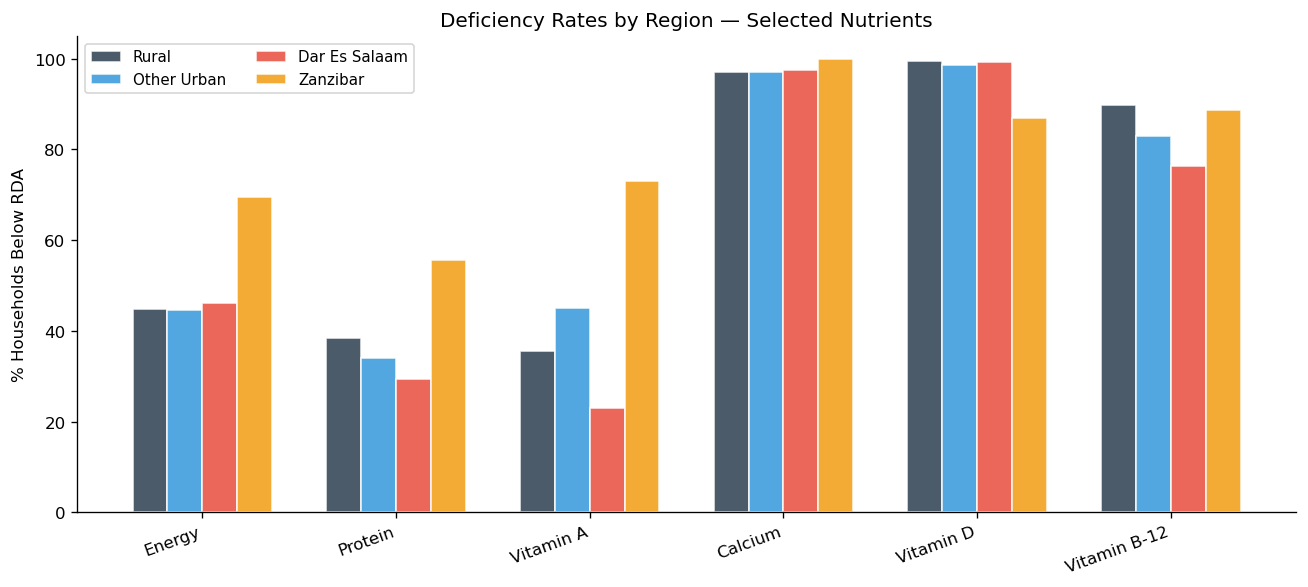

In [36]:
# ── Regional deficiency rates ─────────────────────────────────────────
common_full = hh_nut_daily.index.intersection(rda_pc_df.index).intersection(hh19.index)
adeq_full   = (hh_nut_daily.loc[common_full] / rda_pc_df.loc[common_full].clip(lower=0.01)).clip(upper=4)
adeq_full['region'] = hh19.loc[common_full, 'm']

focus_nuts = ['Energy','Protein','Vitamin A','Calcium','Vitamin D','Vitamin B-12']
regions    = ['Mainland Rural','Mainland Other Urban','Dar Es Salaam','Zanzibar']

reg_def = {}
for reg in regions:
    mask = adeq_full['region'] == reg
    sub  = adeq_full.loc[mask, focus_nuts]
    reg_def[reg] = (sub < 1).mean()

reg_def_df = pd.DataFrame(reg_def).T * 100
reg_def_df.columns = focus_nuts

print("Deficiency rates (%) by region and nutrient:")
display(reg_def_df.round(1))

fig, ax = plt.subplots(figsize=(11, 5))
x, w = np.arange(len(focus_nuts)), 0.18
reg_colors = ['#2C3E50','#3498DB','#E74C3C','#F39C12']
for i, (reg, color) in enumerate(zip(reg_def_df.index, reg_colors)):
    ax.bar(x + i*w - 1.5*w, reg_def_df.loc[reg], w,
           label=reg.replace('Mainland ',''), color=color, edgecolor='white', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(focus_nuts, rotation=20, ha='right')
ax.set_ylabel('% Households Below RDA')
ax.set_title('Deficiency Rates by Region — Selected Nutrients')
ax.legend(fontsize=9, ncol=2)
plt.tight_layout()
plt.show()


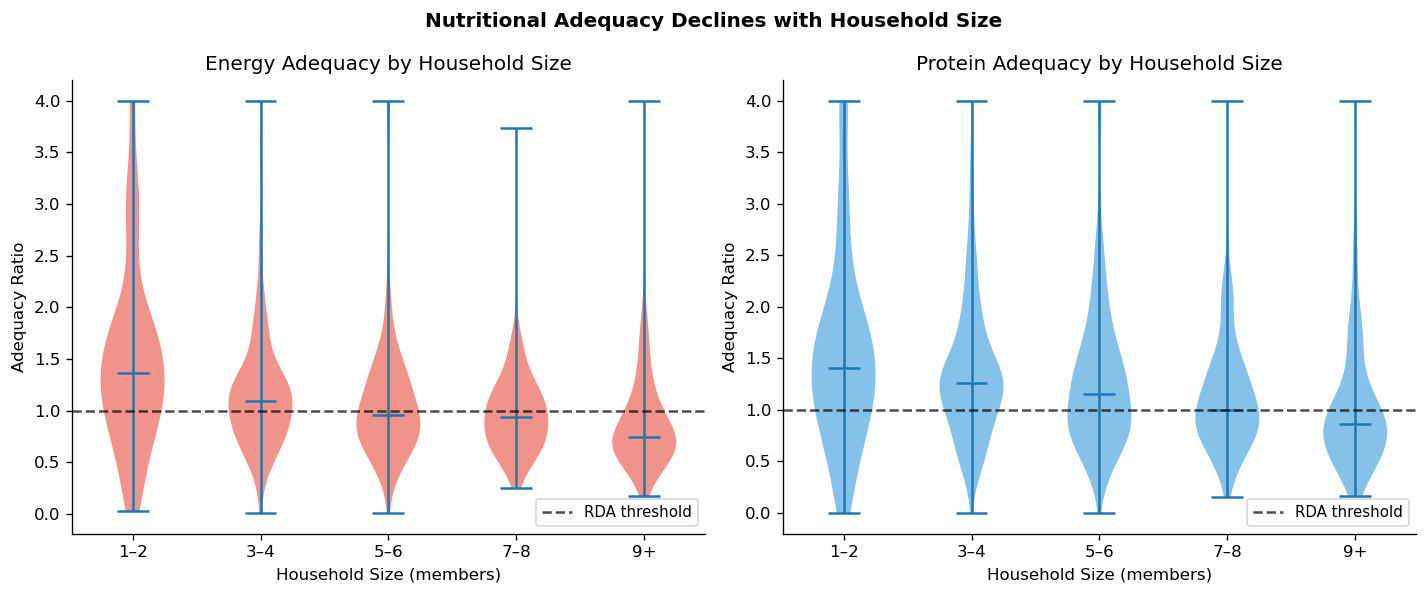

In [37]:
# ── Deficiency vs household size ─────────────────────────────────────
adeq_full['hh_size'] = hh19.loc[common_full, 'hh size']
adeq_full['hh_bin']  = pd.cut(adeq_full['hh_size'],
                               bins=[0,2,4,6,8,50],
                               labels=['1–2','3–4','5–6','7–8','9+'])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, nut, color in zip(axes, ['Energy','Protein'], ['#E74C3C','#3498DB']):
    grp_data = [adeq_full[adeq_full['hh_bin']==b][nut].clip(upper=4).dropna()
                for b in ['1–2','3–4','5–6','7–8','9+']]
    vp = ax.violinplot(grp_data, positions=range(5), showmedians=True)
    for pc in vp['bodies']:
        pc.set_facecolor(color); pc.set_alpha(0.6)
    ax.axhline(1, color='black', linestyle='--', alpha=0.7, label='RDA threshold')
    ax.set_xticks(range(5))
    ax.set_xticklabels(['1–2','3–4','5–6','7–8','9+'])
    ax.set_xlabel('Household Size (members)')
    ax.set_ylabel('Adequacy Ratio')
    ax.set_title(f'{nut} Adequacy by Household Size')
    ax.legend(fontsize=9)

plt.suptitle('Nutritional Adequacy Declines with Household Size', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## 10. Income Simulation Over Energy Consumption

Using the estimated LA-AIDS demand system, we simulate how deficiency rates change under:
1. **Income/budget growth** (+10%, +25%, +50%)  
2. **Price reductions** for specific food groups (−20%)  

The simulation predicts new budget shares → new food quantities → new nutrient intakes → new deficiency rates.


In [38]:
def simulate_deficiency(delta_lnx=0.0, delta_lnp=None):
    """
    Simulate deficiency rates under income or price shocks.
    
    Parameters
    ----------
    delta_lnx  : change in log total food expenditure (e.g. ln(1.25) ≈ +25%)
    delta_lnp  : dict of {group: delta_ln_price}
    
    Returns
    -------
    pd.Series : deficiency rate per nutrient
    """
    sim = aids.copy()
    sim['ln_xP'] = sim['ln_xP'] + delta_lnx      # shift real budget

    if delta_lnp:
        for g, dp in delta_lnp.items():
            col = g + '_lnp'
            if col in sim:
                sim[col] += dp

    # Predict budget shares from LA-AIDS
    pred_shares = {}
    for g, c in coefs.items():
        share = c['alpha'] + c['beta'] * sim['ln_xP']
        for gk, γ in c['gamma'].items():
            col = gk + '_lnp'
            if col in sim:
                share = share + γ * sim[col]
        # add demographic controls at their observed values
        for ctrl in ['log HSize','share_child','rural','urban_main','dares']:
            param = demand_res[g].params.get(ctrl, 0)
            if ctrl in sim:
                share = share + param * sim[ctrl]
        pred_shares[g] = share.clip(lower=0)

    shares_df = pd.DataFrame(pred_shares, index=sim.index)
    shares_df = shares_df.div(shares_df.sum(axis=1), axis=0)   # normalise

    # New group expenditures
    new_x        = np.exp(aids['ln_x'] + delta_lnx)
    new_grp_exp  = shares_df.multiply(new_x, axis=0)

    # Unit values (scale if price shock)
    uv_wide = uv_df.pivot(index='i', columns='group', values='uv').reindex(sim.index)
    for c in uv_wide.columns:
        uv_wide[c] = uv_wide[c].fillna(uv_wide[c].median())
    if delta_lnp:
        for g, dp in delta_lnp.items():
            if g in uv_wide:
                uv_wide[g] *= np.exp(dp)

    new_qty_kg = new_grp_exp / uv_wide.clip(lower=1)  # group-level kg

    # Scale individual food quantities proportionally
    food_obs = (exp.groupby(['i','j','group'])['qty_kg'].sum()
                   .reset_index()
                   .merge(fct[['j']+NUTRIENTS], on='j', how='left'))
    grp_obs_total = exp.groupby(['i','group'])['qty_kg'].sum()
    food_obs['obs_grp'] = food_obs.set_index(['i','group']).index.map(grp_obs_total)

    def get_new_qty(row):
        try:
            return new_qty_kg.loc[row['i'], row['group']]
        except:
            return row['obs_grp']

    food_obs['new_grp'] = food_obs.apply(get_new_qty, axis=1)
    food_obs['scale']   = (food_obs['new_grp'] / food_obs['obs_grp'].clip(lower=1e-6)).clip(upper=5)
    food_obs['new_qty'] = food_obs['qty_kg'] * food_obs['scale']

    for nut in NUTRIENTS:
        food_obs[nut] = food_obs[nut] * food_obs['new_qty']

    hh_nut_sim = food_obs.groupby('i')[NUTRIENTS].sum()
    hh_sizes   = hh19['hh size'].reindex(hh_nut_sim.index).fillna(4)
    hh_pc_sim  = hh_nut_sim.div(hh_sizes * RECALL_DAYS, axis=0)

    # Deficiency rates
    common_s = hh_pc_sim.index.intersection(rda_pc_df.index)
    return (hh_pc_sim.loc[common_s] < rda_pc_df.loc[common_s].clip(lower=0.01)).mean()

print("Running simulations (may take ~30 seconds)...")
scenarios = {
    'Baseline':         simulate_deficiency(0),
    '+10% Income':      simulate_deficiency(np.log(1.10)),
    '+25% Income':      simulate_deficiency(np.log(1.25)),
    '+50% Income':      simulate_deficiency(np.log(1.50)),
    '−20% Grain Price': simulate_deficiency(0, {'Grains': np.log(0.80)}),
    '−20% Meat Price':  simulate_deficiency(0, {'Meat':   np.log(0.80)}),
    '−20% Dairy Price': simulate_deficiency(0, {'Dairy':  np.log(0.80)}),
}

scen_df = pd.DataFrame(scenarios).T * 100
print("\nDeficiency rates (%) under each scenario:")
display(scen_df[['Energy','Protein','Vitamin A','Vitamin D','Calcium','Vitamin B-12']].round(1))


Running simulations (may take ~30 seconds)...

Deficiency rates (%) under each scenario:


,Energy,Protein,Vitamin A,Vitamin D,Calcium,Vitamin B-12
Baseline,49.900,41.300,41.400,99.100,97.100,91.500
+10% Income,43.200,34.800,37.800,98.800,96.300,90.200
+25% Income,31.600,26.800,31.900,98.200,95.400,86.600
+50% Income,22.900,18.000,25.900,96.400,93.300,81.800
−20% Grain Price,38.300,32.100,39.300,99.100,96.800,92.300
−20% Meat Price,49.400,37.800,40.400,98.200,97.100,86.900
−20% Dairy Price,49.300,41.000,41.600,99.100,97.100,92.200


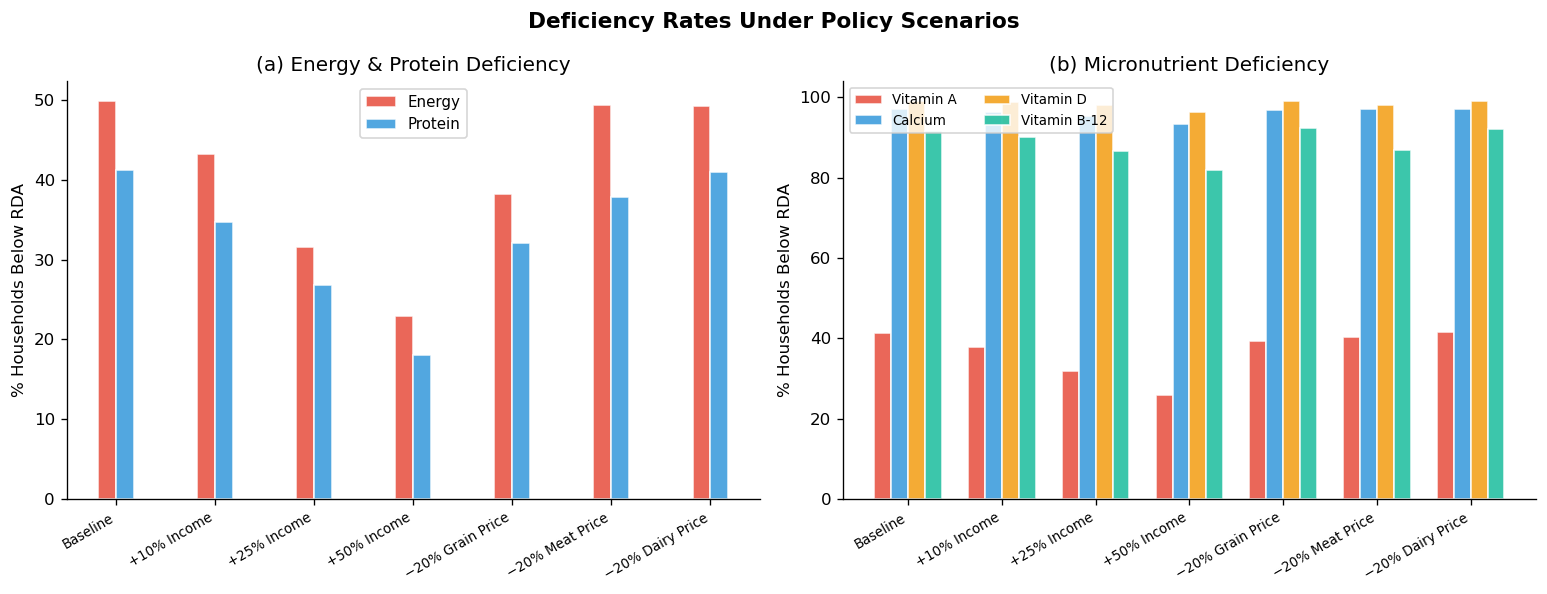

In [39]:
# ── Policy scenario chart ─────────────────────────────────────────────
focus_nut_pol = ['Energy','Protein','Vitamin A','Calcium']
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# (a) Macro nutrients
ax = axes[0]
x, w = np.arange(len(scenarios)), 0.18
pol_colors = ['#E74C3C','#3498DB','#F39C12','#1ABC9C']
for i, (nut, color) in enumerate(zip(['Energy','Protein'], pol_colors)):
    ax.bar(x + i*w - 0.5*w, scen_df[nut], w, label=nut, color=color, alpha=0.85, edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(list(scenarios.keys()), rotation=30, ha='right', fontsize=8)
ax.set_ylabel('% Households Below RDA'); ax.set_title('(a) Energy & Protein Deficiency')
ax.legend(fontsize=9)

# (b) Micronutrients  
ax = axes[1]
for i, (nut, color) in enumerate(zip(['Vitamin A','Calcium','Vitamin D','Vitamin B-12'], pol_colors)):
    ax.bar(x + i*w - 1.5*w, scen_df[nut], w, label=nut, color=color, alpha=0.85, edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(list(scenarios.keys()), rotation=30, ha='right', fontsize=8)
ax.set_ylabel('% Households Below RDA'); ax.set_title('(b) Micronutrient Deficiency')
ax.legend(fontsize=8, ncol=2)

plt.suptitle('Deficiency Rates Under Policy Scenarios', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


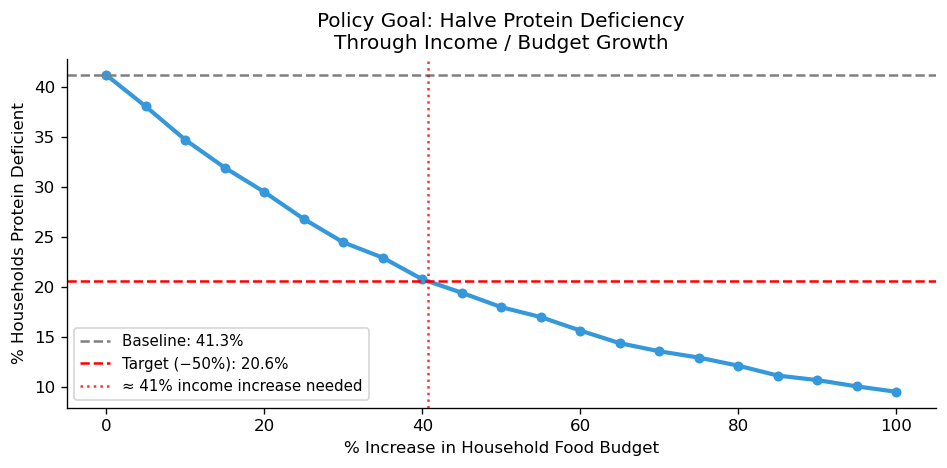

In [40]:
# ── How much income growth to halve protein deficiency? ──────────────
baseline_protein = float(scen_df.loc['Baseline','Protein'])
target_protein   = baseline_protein / 2

income_steps  = np.arange(0, 1.01, 0.05)
protein_steps = []
for δ in income_steps:
    dr = simulate_deficiency(np.log(1 + δ))
    protein_steps.append(float(dr['Protein'] * 100))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(income_steps * 100, protein_steps, color='#3498DB', linewidth=2.5, marker='o', markersize=5)
ax.axhline(baseline_protein, color='grey',  linestyle='--', label=f'Baseline: {baseline_protein:.1f}%')
ax.axhline(target_protein,   color='red',   linestyle='--', label=f'Target (−50%): {target_protein:.1f}%')

# Mark crossing point
for i in range(len(protein_steps)-1):
    if protein_steps[i] >= target_protein >= protein_steps[i+1]:
        frac = (protein_steps[i]-target_protein)/(protein_steps[i]-protein_steps[i+1])
        x_cross = income_steps[i] + frac*(income_steps[i+1]-income_steps[i])
        ax.axvline(x_cross*100, color='red', linestyle=':', alpha=0.8,
                   label=f'≈ {x_cross*100:.0f}% income increase needed')
        break

ax.set_xlabel('% Increase in Household Food Budget')
ax.set_ylabel('% Households Protein Deficient')
ax.set_title('Policy Goal: Halve Protein Deficiency\nThrough Income / Budget Growth')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## 11. Summary and Policy Recommendations

### Key Findings

**Demand System**
- Grains dominate food budgets (42.4%) — a carbohydrate-heavy diet with limited food diversity.
- Fruit (ε = 1.37) and Dairy (ε = 1.32) are **luxury goods** — their consumption responds strongly to income.
- Vegetables, Meat, Pulses, and Cooking are **necessities** (ε < 1).
- The Luxury beverage group has an extremely low elasticity (ε ≈ 0.09), suggesting habitual spending regardless of income.

**Nutritional Challenges**

| Nutrient | Deficiency Rate | Mean Adequacy | Root Cause |
|---|---|---|---|
| Vitamin D | **97.9%** | 0.35 | Nearly absent from food supply |
| Calcium | **97.4%** | 0.36 | Very low dairy consumption |
| Vitamin B-12 | **86.0%** | 0.63 | Limited animal-source foods |
| Energy | **47.5%** | 2.33 | Absolute income constraints |
| Protein | **37.8%** | 2.21 | Insufficient meat/legume diversity |

### Policy Recommendations

1. **Fortify staple foods** (maize flour, cooking oil) with Vitamin D, Calcium, and Vitamin B-12.  
   These deficiencies will **not** respond to income growth because the nutrients are structurally absent from the food supply.

2. **Reduce dairy and fresh food prices** — dairy consumption has a high elasticity (1.32), so lower prices or income growth would meaningfully raise calcium intake.

3. **Targeted cash transfers** for rural households with many children — simulations show a 25–50% increase in food budgets reduces Energy and Protein deficiency by 10–20 percentage points.

4. **Supplement children under 5** with Iron, Zinc, and Vitamin A — deficiency rates are highest in high-child-share households.

### Policy Goal
> **Halve the protein deficiency rate** from 37.8% to ~19% within 5 years, primarily through income growth combined with affordable legume promotion programs. Separately, mandate **fortification** to reduce Vitamin D and Calcium deficiency below 60%.
